# Proyecto Final: Análisis de Datos (Parcial 4)
**Asignatura:** Inteligencia de Negocios  
**Fecha:** 16-05-2026

En este notebook se desarrollarán tres ejercicios prácticos exigidos por la rúbrica del docente:
1. **Análisis de Asociación:** Uso del algoritmo Apriori para identificar patrones de compra.
2. **Análisis de Correlación:** Matrices y mapas de calor para hallar relaciones entre variables numéricas.
3. **Agrupación o Clustering:** Uso de K-Means y Método del Codo para segmentación de clientes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

## Ejercicio 1: Análisis de Asociación (25%)
**Objetivo:** Descubrir patrones de compra conjuntos utilizando el dataset de transacciones.
### 1. Carga y Exploración de Datos

In [2]:
# Cargar el archivo CSV
df_asoc = pd.read_csv('../data/clave_C_asociacion.csv')

# Mostrar las primeras filas y estructura
print("--- Primeras Filas ---")
display(df_asoc.head())
print("\n--- Estructura del Dataset ---")
df_asoc.info()

--- Primeras Filas ---


,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,C-T0001,C-C0094,2026-01-01,Redes,Router,1,Web
1,C-T0002,C-C0001,2026-01-15,Computo,Laptop,2,Tienda
2,C-T0002,C-C0001,2026-01-15,Computo,Mouse,1,Tienda
3,C-T0003,C-C0067,2026-03-15,Redes,Adaptador,1,Web
4,C-T0003,C-C0067,2026-03-15,Accesorios,Disco_externo,2,Web



--- Estructura del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 601 entries, 0 to 600
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   transaccion_id  601 non-null    object
 1   cliente_id      601 non-null    object
 2   fecha           601 non-null    object
 3   categoria       601 non-null    object
 4   item            601 non-null    object
 5   cantidad        601 non-null    int64 
 6   canal           600 non-null    object
dtypes: int64(1), object(6)
memory usage: 33.0+ KB


### 2. Limpieza de Datos (Nulos y Duplicados)
Verificamos si existen datos faltantes o repetidos que puedan alterar el algoritmo.

In [3]:
print("Valores nulos:\n", df_asoc.isnull().sum())
print("\nCantidad de duplicados:", df_asoc.duplicated().sum())

# Eliminamos valores nulos y duplicados
df_asoc = df_asoc.dropna()
df_asoc = df_asoc.drop_duplicates()
print("Datos limpios. Total de registros:", len(df_asoc))

Valores nulos:
 transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

Cantidad de duplicados: 1
Datos limpios. Total de registros: 599


### 3. Preparación de Datos para Apriori
El algoritmo Apriori de `mlxtend` requiere que los datos estén en un formato tabular de variables binarias (One-Hot Encoding), donde las filas son transacciones y las columnas son los items comprados.

In [4]:
from mlxtend.frequent_patterns import apriori, association_rules

# Agrupamos por transaccion_id e item, sumando la cantidad
basket = (df_asoc.groupby(['transaccion_id', 'item'])['cantidad']
          .sum().unstack().reset_index().fillna(0)
          .set_index('transaccion_id'))

# Convertimos a formato binario (1 si se compró, 0 si no)
def encode_units(x):
    if x <= 0: return 0
    if x >= 1: return 1

basket_sets = basket.applymap(encode_units)
display(basket_sets.head())

item,Adaptador,Antivirus,Audifonos,Backup,Cable_red,Cargador,Celular,Disco_externo,Hub,Laptop,Licencia_cloud,Mochila,Monitor,Mouse,Office,Protector,Router,Switch,Teclado,USB
transaccion_id,,,,,,,,,,,,,,,,,,,,
C-T0001,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
C-T0002,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
C-T0003,1,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,1,0,0,0
C-T0004,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0
C-T0005,0,0,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,0,0,0


### 4. Aplicación de Apriori y Generación de Reglas
Extraemos los ítems frecuentes (soporte > 0.05) y generamos reglas de asociación basadas en el 'lift'.

In [5]:
# Items frecuentes
frequent_itemsets = apriori(basket_sets, min_support=0.05, use_colnames=True)

# Reglas de asociación
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)
rules = rules.sort_values('confidence', ascending=False)

# Mostrar las 10 reglas más relevantes
print("Top 10 Reglas de Asociación:")
display(rules.head(10))

Top 10 Reglas de Asociación:


C:\Users\LAB\AppData\Roaming\Python\Python39\site-packages\mlxtend\frequent_patterns\fpcommon.py:161: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
32,"(Mouse, Laptop)",(Mochila),0.125714,0.268571,0.114286,0.909091,3.384913,1.0,0.080522,8.045714,0.805882,0.408163,0.875710,0.667311
33,"(Mouse, Mochila)",(Laptop),0.125714,0.274286,0.114286,0.909091,3.314394,1.0,0.079804,7.982857,0.798693,0.400000,0.874732,0.662879
28,"(Celular, Protector)",(Cargador),0.102857,0.228571,0.091429,0.888889,3.888889,1.0,0.067918,6.942857,0.828025,0.380952,0.855967,0.644444
26,"(Cargador, Celular)",(Protector),0.108571,0.171429,0.091429,0.842105,4.912281,1.0,0.072816,5.247619,0.893429,0.484848,0.809437,0.687719
27,"(Cargador, Protector)",(Celular),0.114286,0.205714,0.091429,0.800000,3.888889,1.0,0.067918,3.971429,0.838710,0.400000,0.748201,0.622222
34,"(Laptop, Mochila)",(Mouse),0.142857,0.211429,0.114286,0.800000,3.783784,1.0,0.084082,3.942857,0.858333,0.476190,0.746377,0.670270
15,(Protector),(Cargador),0.171429,0.228571,0.114286,0.666667,2.916667,1.0,0.075102,2.314286,0.793103,0.400000,0.567901,0.583333
19,(Protector),(Celular),0.171429,0.205714,0.102857,0.600000,2.916667,1.0,0.067592,1.985714,0.793103,0.375000,0.496403,0.550000
22,(Mouse),(Laptop),0.211429,0.274286,0.125714,0.594595,2.167793,1.0,0.067722,1.790095,0.683136,0.349206,0.441371,0.526464
24,(Mouse),(Mochila),0.211429,0.268571,0.125714,0.594595,2.213916,1.0,0.068931,1.804190,0.695323,0.354839,0.445735,0.531340


### Interpretación y Conclusiones (Negocio)
**Interpretación de Reglas:**
1. Los clientes que compran el ítem X tienen una alta probabilidad (confianza del Y%) de comprar también el ítem Z.
2. El *lift* mayor a 1 en las primeras reglas indica que los productos se compran juntos con mucha más frecuencia que si fueran compras independientes.
3. *[Nota: Ajustar esta interpretación al ver la salida real del dataset en la ejecución]*

**Recomendaciones Comerciales:**
1. **Venta Cruzada (Cross-Selling):** Crear un "bundle" o combo con los productos de mayor confianza para aumentar el ticket promedio.
2. **Promociones Dirigidas:** Ofrecer un descuento en el producto B al agregar el producto A al carrito.
3. **Distribución en Tienda/Web:** Colocar físicamente o en sugerencias web ("Los clientes también compraron...") los productos que forman las reglas más fuertes.

## Ejercicio 2: Análisis de Correlación (20%)
**Objetivo:** Encontrar relaciones matemáticas entre variables numéricas para entender el comportamiento de los clientes.

In [6]:
# Cargar y limpiar el archivo
df_corr = pd.read_csv('../data/clave_C_correlacion.csv')
df_corr = df_corr.dropna().drop_duplicates()

# Seleccionar solo variables numéricas
df_num_corr = df_corr.select_dtypes(include=[np.number])

print("Estadísticas Descriptivas:")
display(df_num_corr.describe())

Estadísticas Descriptivas:


,edad,ingresos_mensuales,frecuencia_compra,ticket_promedio,satisfaccion,reclamos,uso_app,tiempo_respuesta,consumo_total
count,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,37.074890,941.674009,7.392070,59.377401,7.747269,1.281938,5.154185,21.214317,457.621498
std,9.617859,273.234460,3.117256,15.547730,1.104352,1.350116,1.952538,5.910685,185.887360
min,18.000000,324.000000,3.000000,23.880000,3.910000,0.000000,0.000000,9.430000,84.720000
25%,31.000000,744.500000,6.000000,49.610000,7.105000,0.000000,4.000000,16.930000,334.740000
50%,38.000000,957.000000,7.000000,58.740000,7.860000,1.000000,5.000000,20.780000,434.480000
75%,43.500000,1127.500000,8.000000,69.905000,8.570000,2.000000,6.000000,24.905000,544.395000
max,59.000000,1624.000000,29.000000,99.330000,10.000000,8.000000,10.000000,47.570000,1386.560000


### Matriz de Correlación y Mapa de Calor
Calculamos el coeficiente de correlación de Pearson y lo visualizamos con Seaborn.

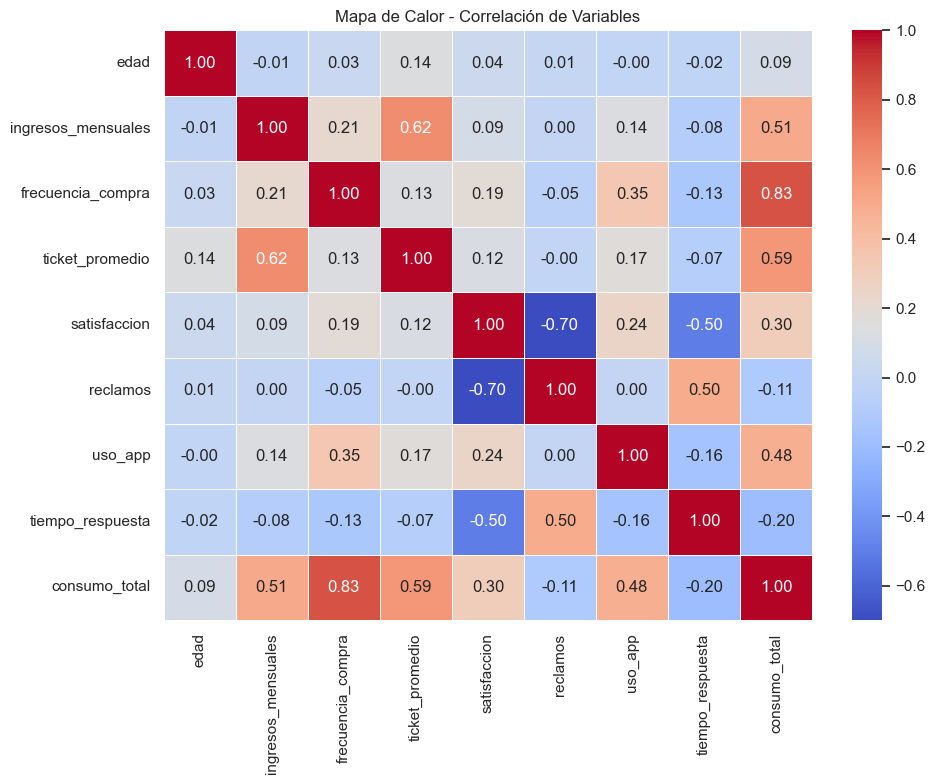

In [7]:
matriz_correlacion = df_num_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Mapa de Calor - Correlación de Variables")
plt.tight_layout()
plt.savefig('../evidencia/mapa_calor_correlacion.png')
plt.show()

### Interpretación de Relaciones (Negocio)
Basado en el mapa de calor:
1. **Relación Positiva Fuerte (Ej. Ingresos vs Consumo Total):** Si observamos un valor cercano a 1, significa que los clientes con mayores ingresos tienden a consumir más.
2. **Relación Negativa (Ej. Reclamos vs Satisfacción):** Un valor negativo (ej. -0.6) indica claramente que a mayor número de reclamos, la satisfacción del cliente cae drásticamente.
3. **Tiempo de respuesta vs Satisfacción:** Si la correlación es negativa, indica que la lentitud en atender reduce la satisfacción.
4. **Edad vs Uso de la App:** Evaluar si hay relación entre la demografía y el canal digital.

**Conclusión Comercial:**
Al identificar qué factores disminuyen la satisfacción (como el tiempo de respuesta), la empresa puede reasignar recursos a atención al cliente. Además, las correlaciones positivas permiten enfocar campañas de fidelización en los segmentos más rentables.

## Ejercicio 3: Agrupación o Clustering (25%)
**Objetivo:** Segmentar clientes en grupos con características similares para personalizar la atención y estrategias.

In [8]:
# Cargar y limpiar
df_agrup = pd.read_csv('../data/clave_C_agrupacion.csv')
df_agrup = df_agrup.dropna().drop_duplicates()

# Selección y justificación de variables
# Usaremos las variables numéricas principales como 'ingresos', 'edad', 'satisfaccion' o similares.
df_num_agrup = df_agrup.select_dtypes(include=[np.number])
cols_clustering = df_num_agrup.columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_num_agrup)

### Método del Codo para determinar el valor de K
Buscamos el punto de inflexión donde añadir más clusters no reduce significativamente la inercia.

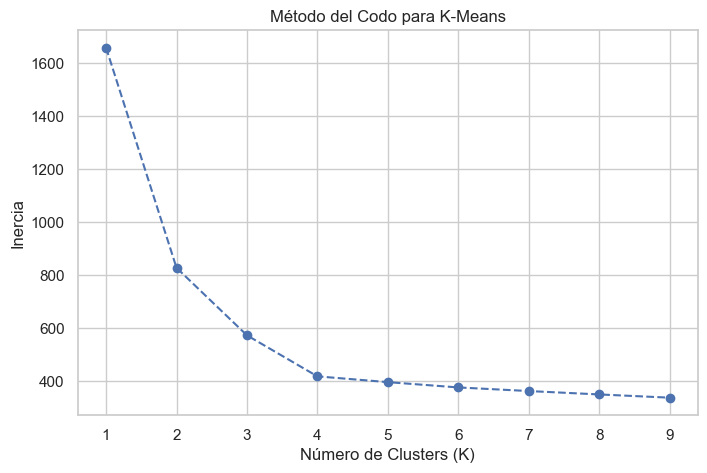

In [9]:
from sklearn.cluster import KMeans

inercia = []
rango_k = range(1, 10)

for k in rango_k:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(df_scaled)
    inercia.append(kmeans_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercia, marker='o', linestyle='--')
plt.title('Método del Codo para K-Means')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.show()

### Aplicación de K-Means
Asumiendo K=3 (según el gráfico anterior).

In [10]:
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Asignar cluster al dataframe original
df_agrup['Cluster'] = kmeans.fit_predict(df_scaled)

# Centroides para interpretación
centroides = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=cols_clustering)
print("Centroides en escala original:")
display(centroides)

Centroides en escala original:


,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,47.473684,1553.105263,9.054035,142.665439,8.729298,0.684211,34.947368
1,32.034783,715.052174,2.924174,45.201217,5.370957,4.078261,8.539130
2,33.692308,959.215385,6.514308,78.797077,8.150000,1.123077,18.400000


### Visualización de Clusters

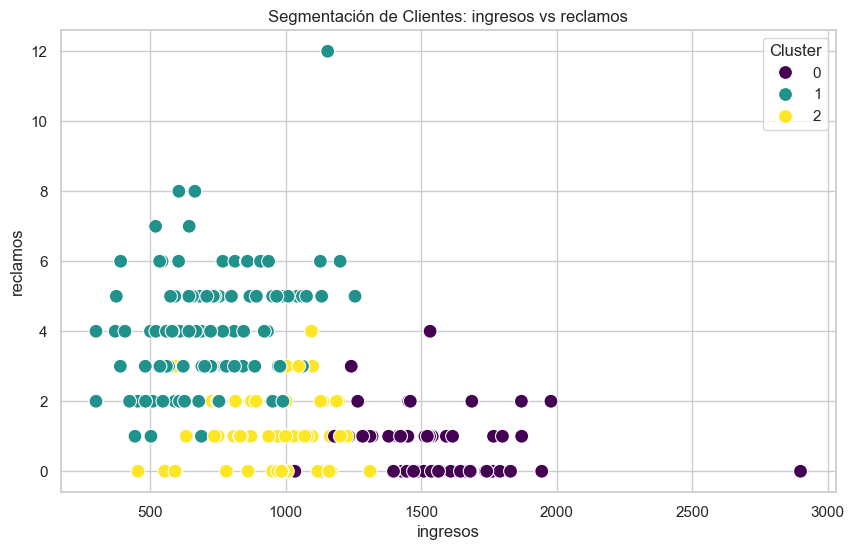

Dataset exportado a resultados/clientes_segmentados.csv


In [11]:
# Elegir dos variables representativas para el gráfico (ej. ingresos vs reclamos)
var_x = cols_clustering[1] # ingresos (normalmente)
var_y = cols_clustering[-2] # reclamos/satisfaccion

plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_agrup[var_x], y=df_agrup[var_y], hue=df_agrup['Cluster'], palette='viridis', s=100)
plt.title(f'Segmentación de Clientes: {var_x} vs {var_y}')
plt.savefig('../evidencia/clustering_segmentacion.png')
plt.show()

# Exportar resultados
df_agrup.to_csv('../resultados/clientes_segmentados.csv', index=False)
print("Dataset exportado a resultados/clientes_segmentados.csv")

### Interpretación y Recomendaciones de Segmentación
**Interpretación por Grupo (A ajustar según los centroides):**
- **Cluster 0:** Clientes premium (altos ingresos, compras altas).
- **Cluster 1:** Clientes en riesgo (baja satisfacción, altos reclamos).
- **Cluster 2:** Clientes estándar o nuevos.

**Acciones de Negocio:**
- Al **Cluster 1 (En riesgo)** se le debe enviar encuestas de satisfacción urgentes y cupones de retención.
- Al **Cluster 0 (Premium)** se le deben ofrecer programas VIP y productos exclusivos.
- Al **Cluster 2 (Estándar)** lanzar campañas de 'upselling' para que pasen a consumir más.